# ETF 动量轮动策略 — 完整回测报告

**最终推荐**：C 版（优化池 + 估值约束）

| 指标 | A. 原始 (21只) | B. 优化池 (17只) | **C. 池优化+估值 (推荐)** | CSI 300 B&H |
|------|:---:|:---:|:---:|:---:|
| 年化收益 | 4.08% | 3.58% | **3.93%** | 4.88% |
| 年化波动 | 13.27% | 12.79% | **9.90%** | 20.59% |
| 夏普 | 0.16 | 0.12 | **0.19** | — |
| 最大回撤 | -23.66% | -20.43% | **-12.19%** | -44.75% |
| 月胜率 | 47.44% | 47.44% | **53.85%** | — |
| 超额年化 | -0.81% | -1.31% | -0.96% | — |

**策略逻辑**：
1. 趋势过滤器：沪深300 vs MA200 → 权益仓位上限 (100%/30%)
2. 估值约束：A股 PB 10年分位数 → 仓位系数 (0.5/0.7/0.9/1.0)
3. 波动率校准：目标 15% 年化波动
4. 横截面动量：(60日 + 120日收益)/2 → 排名
5. 相关性剔除：> 0.8 跳过 → 选 Top 5 → 等权

In [30]:
# ============================================================
#  Imports + 代理绕过 (真正幂等，重复运行安全)
# ============================================================
import os, sys, time, warnings
from datetime import datetime
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 代理绕过
# 关键：不要覆写 __init__（会递归），只要预设 trust_env + proxies
import requests as _r
if not getattr(_r.Session, "_proxy_patched", False):
    for _k in list(os.environ):
        if "proxy" in _k.lower():
            del os.environ[_k]
    import urllib.request
    urllib.request.getproxies = lambda: {}
    # 类属性：新 Session 默认 trust_env=False
    _r.Session.trust_env = False
    _r.Session.proxies = {"http": None, "https": None}  # 会被 instance 继承
    _r.Session._proxy_patched = True

print(f"pandas {pd.__version__}  |  numpy {np.__version__}")

pandas 2.2.3  |  numpy 2.4.6


In [31]:
# ============================================================
#  ETF 标的池 (优化版 17 只)
# ============================================================
# 移除: 科创50(588000) 恒生科技(513180) 光伏(515790) 新能源(516160)
# 理由: 上市晚(2020年底~2021年) 前段数据缺失 动量排名失真
ETF_UNIVERSE = {
    "510300": "沪深300", "510050": "上证50", "510500": "中证500",
    "512100": "中证1000", "159949": "创业板50",
    "159928": "消费", "512010": "医药",
    "512880": "证券", "512800": "银行",
    "512660": "军工", "159995": "芯片",
    "513100": "纳指", "513050": "中概互联",
    "518880": "黄金",
    "511010": "国债", "511260": "十年国债", "511380": "可转债",
}
DEFENSIVE_ETF = "511010"
BENCHMARK_ETF = "510300"
CACHE_DIR = os.path.join(os.path.abspath('.'), 'etf_cache')
os.makedirs(CACHE_DIR, exist_ok=True)
print(f'ETF 池: {len(ETF_UNIVERSE)} 只, 缓存: {CACHE_DIR}')

ETF 池: 17 只, 缓存: d:\qu\quant intern\量化的另一条路\etf_cache


In [32]:
# ============================================================
#  数据获取
# ============================================================
def fetch_etf_universe(start="2020-01-01", end=None, force_refresh=False):
    """加载 ETF 数据。缓存存在 → 直接用，绝不碰网络。"""
    if end is None: end = datetime.today().strftime("%Y-%m-%d")
    data = {}
    start_ts = pd.Timestamp(start)  # pd.Timestamp 比较，不是字符串比较

    for code, name in ETF_UNIVERSE.items():
        cf = os.path.join(CACHE_DIR, f"{code}.csv")

        # 缓存存在且起始日期 ≤ start → 直接用
        if not force_refresh and os.path.exists(cf):
            df = pd.read_csv(cf, index_col=0, parse_dates=True)
            if not df.empty and df.index[0] <= start_ts:
                data[code] = df
                continue

        # 缓存存在但起始日期 > start（新ETF，如511380从2020-04才开始）
        # → 缓存够用，直接读
        if not force_refresh and os.path.exists(cf):
            df = pd.read_csv(cf, index_col=0, parse_dates=True)
            if not df.empty:
                data[code] = df
                continue

        # 真没缓存 — 跳过，不碰网络
        print(f"  [跳过] {code} {name}: 无缓存文件")

    print(f"[加载] {len(data)}/{len(ETF_UNIVERSE)} 只 ETF 从缓存就绪")
    return data

def align_universe(raw_data, min_da=50_000_000):
    cl = {c: d["close"] for c, d in raw_data.items()}
    am = {c: d.get("amount", pd.Series(0, index=d.index)) for c, d in raw_data.items()}
    px = pd.DataFrame(cl).sort_index().dropna(how="all")
    avg = pd.DataFrame(am).reindex(px.index).mean()
    v = [c for c, a in avg.items() if a >= min_da]
    if len(v) < 10:
        v = [c for c, a in avg.items() if a >= min_da / 5]
    print(f"[标的池] {len(v)} 只, {px.index[0].date()} ~ {px.index[-1].date()}")
    return px[v], v

print("数据函数定义完成。（纯缓存模式，零网络请求）")

数据函数定义完成。（纯缓存模式，零网络请求）


In [33]:
# ============================================================
#  加载 ETF 数据 + PB 分位数
# ============================================================
raw_data = fetch_etf_universe(start="2020-01-01", force_refresh=False)
price_matrix, valid_codes = align_universe(raw_data)
print(f"价格矩阵: {price_matrix.shape[0]}d x {price_matrix.shape[1]} ETFs")

# PB 分位数 — 从本地 CSV 读（不碰网络，不碰 akshare）
pb_df = pd.read_csv("pb_cache.csv", index_col=0, parse_dates=True)
print(f"PB 分位数: 最近 {pb_df['pb_pct'].iloc[-1]:.0%}, "
      f"范围 {pb_df['pb_pct'].min():.0%}~{pb_df['pb_pct'].max():.0%}")

[加载] 17/17 只 ETF 从缓存就绪
[标的池] 17 只, 2020-01-02 ~ 2026-06-22
价格矩阵: 1565d x 17 ETFs
PB 分位数: 最近 60%, 范围 0%~100%


In [34]:
# ============================================================
#  策略类 (原始 + 估值版)
# ============================================================
class ETFRotationStrategy:
    def __init__(self, mom_windows=(60,120), top_n=5, trend_ma=200,
                 bear_equity_cap=0.30, target_vol=0.15, vol_window=20,
                 corr_threshold=0.80, corr_window=60, rebalance_freq="2W"):
        self.mw = mom_windows; self.top_n = top_n; self.trend_ma = trend_ma
        self.bear_cap = bear_equity_cap; self.tvol = target_vol
        self.vw = vol_window; self.corr_th = corr_threshold
        self.cw = corr_window; self.freq = rebalance_freq

    def generate_signals(self, px, bench="510300", defensive="511010"):
        ret = px.pct_change(); rbd = self._rb_dates(px.index); sigs = []
        for dt in rbd:
            try: p = px.index.get_loc(dt)
            except KeyError: continue
            if p < max(self.trend_ma, max(self.mw), self.cw): continue
            ps = px.iloc[:p+1]; rs = ret.iloc[:p+1]
            ew = self._trend(ps, bench) * self._vol(ps, bench)
            sel = self._corr(self._mom(ps), rs)
            if len(sel)==0: sel,wts=[defensive],{defensive:1.0}; ew=0.0
            else:
                pw=ew/len(sel); wts={c:pw for c in sel}
                if ew<1.0: wts[defensive]=1.0-ew
            sigs.append(dict(date=dt, equity_weight=ew, selected=sel, weights=wts))
        return pd.DataFrame(sigs).set_index("date")

    def _rb_dates(self, dates):
        iso = dates.isocalendar()
        y = iso["year"] if isinstance(iso, pd.DataFrame) else iso.year
        w = iso["week"] if isinstance(iso, pd.DataFrame) else iso.week
        wid = y.values*100 + w.values
        df = pd.DataFrame({"d":dates,"wid":wid})
        weekly = pd.DatetimeIndex(df.groupby("wid")["d"].last().sort_values())
        return weekly[::2] if self.freq=="2W" else weekly

    def _trend(self, px, bench):
        if bench not in px.columns: return self.bear_cap
        bp = px[bench].dropna()
        if len(bp) < self.trend_ma: return self.bear_cap
        return 1.0 if bp.iloc[-1] > bp.rolling(self.trend_ma).mean().iloc[-1] else self.bear_cap

    def _vol(self, px, bench):
        if bench not in px.columns: return 1.0
        bp = px[bench].dropna()
        if len(bp) < self.vw+1: return 1.0
        lr = np.log(bp/bp.shift(1)).dropna().iloc[-self.vw:]
        av = lr.std()*np.sqrt(252)
        return min(1.0, self.tvol/av) if av>0 else 1.0

    def _mom(self, px):
        sc = pd.Series(index=px.columns, dtype=float)
        for c in px.columns:
            p = px[c].dropna()
            if len(p) < max(self.mw): sc[c]=-np.inf; continue
            wins = [p.iloc[-1]/p.iloc[-w]-1 for w in self.mw if len(p)>=w]
            sc[c] = np.mean(wins) if wins else -np.inf
        return sc.sort_values(ascending=False)

    def _corr(self, ms, rs):
        cr = rs.iloc[-self.cw:]; sel = []
        for c in ms.index:
            if ms[c] == -np.inf or c not in cr.columns: continue
            skip = False
            for s in sel:
                pair = cr[[c,s]].dropna()
                if len(pair) >= 20 and abs(pair.corr().iloc[0,1]) > self.corr_th:
                    skip = True; break
            if not skip: sel.append(c)
            if len(sel) >= self.top_n: break
        return sel


class ValuationStrategy(ETFRotationStrategy):
    """估值约束版：叠加 PB 分位数仓位系数"""
    def __init__(self, pb_pct_series=None, **kw):
        super().__init__(**kw); self.pb = pb_pct_series

    def _val(self, dt):
        if self.pb is None: return 1.0
        a = self.pb[self.pb.index <= dt]
        if len(a) == 0: return 1.0
        p = a.iloc[-1]
        if pd.isna(p): return 1.0
        if p < 0.20: return 1.0
        elif p < 0.50: return 0.90
        elif p < 0.80: return 0.70
        else: return 0.50

    def generate_signals(self, px, bench="510300", defensive="511010"):
        ret = px.pct_change(); rbd = self._rb_dates(px.index); sigs = []
        for dt in rbd:
            try: p = px.index.get_loc(dt)
            except KeyError: continue
            if p < max(self.trend_ma, max(self.mw), self.cw): continue
            ps = px.iloc[:p+1]; rs = ret.iloc[:p+1]
            ew = self._trend(ps,bench) * self._vol(ps,bench) * self._val(dt)
            sel = self._corr(self._mom(ps), rs)
            if len(sel)==0: sel,wts=[defensive],{defensive:1.0}; ew=0.0
            else:
                pw=ew/len(sel); wts={c:pw for c in sel}
                if ew<1.0: wts[defensive]=1.0-ew
            sigs.append(dict(date=dt, equity_weight=ew, selected=sel, weights=wts))
        return pd.DataFrame(sigs).set_index("date")

print("策略类定义完成。")

策略类定义完成。


In [35]:
# ============================================================
#  回测引擎
# ============================================================
class BacktestEngine:
    def __init__(self, init_cap=100_000, comm=0.00005, slip=0.0005):
        self.ic=init_cap; self.comm=comm; self.slip=slip

    def run(self, px, sig):
        px,sig = px.copy(),sig.copy(); cash=self.ic; hld={}; nvs=[]; trs=[]
        for date in px.index:
            if date in sig.index:
                t,cash=self._rb(date,sig.loc[date,"weights"],hld,cash,px.loc[date].to_dict())
                if t: trs.extend(t)
            hv = sum(sh*px.loc[date].get(c,0) for c,sh in hld.items()
                     if np.isfinite(px.loc[date].get(c,np.nan)))
            nvs.append({"date":date,"nav":cash+hv})
        nav=pd.DataFrame(nvs).set_index("date"); nav["returns"]=nav["nav"].pct_change()
        return {"nav":nav,"trades":pd.DataFrame(trs) if trs else pd.DataFrame(),
                "metrics":self._metrics(nav,px)}

    def _rb(self, date, tw, hld, cash, prices):
        tr=[]
        if not tw: return tr,cash
        cn=cash+sum(sh*prices.get(c,0) for c,sh in hld.items())
        th={c:cn*w for c,w in tw.items() if w>0}
        for c in list(hld.keys()):
            if c not in th:
                sh=hld.pop(c); p=prices.get(c,np.nan)
                if np.isfinite(p) and p>0 and sh>0:
                    ep=p*(1-self.slip); pro=sh*ep; co=sh*p*self.comm
                    cash+=pro-co; tr.append(dict(date=date,code=c,action="sell",shares=sh,price=ep,proceeds=pro,cost=co))
        for c,tv in th.items():
            p=prices.get(c,np.nan)
            if not np.isfinite(p) or p<=0: continue
            cv=hld.get(c,0)*p; diff=tv-cv
            if abs(diff)<cn*0.005: continue
            if diff>0:
                ep=p*(1+self.slip); bv=min(diff,cash); nb=int(bv/ep)
                if nb>0:
                    co=nb*ep; com=co*self.comm; cash-=co+com
                    hld[c]=hld.get(c,0)+nb; tr.append(dict(date=date,code=c,action="buy",shares=nb,price=ep,proceeds=-co,cost=com))
            else:
                ep=p*(1-self.slip); ns=min(int(abs(diff)/p),hld.get(c,0))
                if ns>0:
                    pro=ns*ep; com=pro*self.comm; cash+=pro-com
                    hld[c]-=ns
                    if hld[c]==0: del hld[c]
                    tr.append(dict(date=date,code=c,action="sell",shares=ns,price=ep,proceeds=pro,cost=com))
        return tr,cash

    def _metrics(self, nav, px):
        rets=nav["returns"].dropna()
        if len(rets)<20: return {"error":"data too short"}
        yrs=max((nav.index[-1]-nav.index[0]).days/365.25,0.5)
        tr_ret=nav["nav"].iloc[-1]/nav["nav"].iloc[0]-1
        cagr=(1+tr_ret)**(1/yrs)-1; av=rets.std()*np.sqrt(252)
        sh=(cagr-0.02)/av if av>0 else 0
        dd=((nav["nav"]-nav["nav"].cummax())/nav["nav"].cummax()).min()
        cm=cagr/abs(dd) if dd!=0 else 0
        mo=nav["returns"].resample("ME").apply(lambda x:(1+x).prod()-1)
        wr=(mo>0).mean(); aw=mo[mo>0].mean(); al=mo[mo<0].mean()
        pf=abs(aw*(mo>0).sum()/(al*(mo<0).sum())) if al!=0 and (mo<0).sum()>0 else np.inf
        bi={}
        if "510300" in px.columns:
            b=px["510300"].reindex(nav.index).ffill(); br=b.pct_change().dropna()
            bt=b.iloc[-1]/b.iloc[0]-1; bc=(1+bt)**(1/yrs)-1
            te=(rets-br.reindex(rets.index)).dropna().std()*np.sqrt(252)
            bi=dict(bench_cagr=bc,bench_vol=br.std()*np.sqrt(252),
                    bench_max_dd=((b-b.cummax())/b.cummax()).min(),
                    excess_cagr=cagr-bc,tracking_err=te)
            bi["ir"]=bi["excess_cagr"]/te if te>0 else 0
        return dict(total_return=tr_ret,cagr=cagr,annual_vol=av,sharpe=sh,
                    max_drawdown=dd,calmar=cm,win_rate_monthly=wr,
                    avg_win_monthly=aw,avg_loss_monthly=al,profit_factor=pf,years=yrs,**bi)

print("回测引擎定义完成。")

回测引擎定义完成。


In [36]:
# ============================================================
#  回测：原始版 (参考) + 估值约束版 (推荐)
# ============================================================
DEFAULT = dict(mom_windows=(60,120), top_n=5, trend_ma=200, bear_equity_cap=0.30,
               target_vol=0.15, vol_window=20, corr_threshold=0.80,
               corr_window=60, rebalance_freq="2W")

# --- 原始版 ---
s_orig = ETFRotationStrategy(**DEFAULT)
sig_orig = s_orig.generate_signals(price_matrix)
r_orig = BacktestEngine(100_000).run(price_matrix, sig_orig)
m_orig, nav_orig, tr_orig = r_orig["metrics"], r_orig["nav"], r_orig["trades"]

# --- 估值约束版 ---
s_val = ValuationStrategy(pb_pct_series=pb_df["pb_pct"], **DEFAULT)
sig_val = s_val.generate_signals(price_matrix)
r_val = BacktestEngine(100_000).run(price_matrix, sig_val)
m_val, nav_val, tr_val = r_val["metrics"], r_val["nav"], r_val["trades"]

print(f"原始: {len(sig_orig)} 信号, {len(tr_orig)} 交易, 平均仓位 {sig_orig['equity_weight'].mean()*100:.0f}%")
print(f"估值: {len(sig_val)} 信号, {len(tr_val)} 交易, 平均仓位 {sig_val['equity_weight'].mean()*100:.0f}%")

原始: 144 信号, 718 交易, 平均仓位 60%
估值: 144 信号, 716 交易, 平均仓位 51%


In [37]:
# ============================================================
#  头对头对比
# ============================================================
from collections import OrderedDict

compare = OrderedDict([
    ("原始 (MA200 + 60/120 动量)", m_orig),
    ("估值约束 (MA200 + 60/120 动量 + PB分位)", m_val),
])

rows = [("年化收益","cagr"),("年化波动","annual_vol"),("夏普比率","sharpe"),
        ("最大回撤","max_drawdown"),("Calmar","calmar"),
        ("月胜率","win_rate_monthly"),("超额年化","excess_cagr"),("信息比率","ir")]

print("=" * 75)
print(f"{'指标':<14s}  {'原始':>28s}  {'估值约束 (推荐)':>28s}")
print("-" * 75)
for lb,ky in rows:
    ov = m_orig.get(ky); nv = m_val.get(ky)
    def f(v,k=ky):
        if v is None or (isinstance(v,float) and np.isnan(v)): return "N/A"
        return f"{v*100:7.2f}%" if k not in ("sharpe","calmar","ir") else f"{v:7.2f}"
    print(f"{lb:<14s}  {f(ov):>28s}  {f(nv):>28s}")
print(f"{'交易次数':<14s}  {len(tr_orig):>28d}  {len(tr_val):>28d}")
print(f"{'交易成本':<14s}  {tr_orig['cost'].sum():>26.0f} RMB  {tr_val['cost'].sum():>26.0f} RMB")
print("=" * 75)
ex_o = m_orig.get("excess_cagr",0) or 0
ex_v = m_val.get("excess_cagr",0) or 0
print(f"\n超额: {ex_o*100:+.2f}% → {ex_v*100:+.2f}%  (估值贡献 {ex_v*100-ex_o*100:+.2f}pp)")
print(f"回撤: {m_orig['max_drawdown']*100:.1f}% → {m_val['max_drawdown']*100:.1f}%  (改善 {(m_orig['max_drawdown']-m_val['max_drawdown'])*100:.1f}pp)")
print(f"夏普: {m_orig['sharpe']:.2f} → {m_val['sharpe']:.2f}")

指标                                        原始                     估值约束 (推荐)
---------------------------------------------------------------------------
年化收益                                   3.57%                         3.92%
年化波动                                  12.79%                         9.90%
夏普比率                                    0.12                          0.19
最大回撤                                 -20.48%                       -12.23%
Calmar                                  0.17                          0.32
月胜率                                   47.44%                        53.85%
超额年化                                  -1.32%                        -0.97%
信息比率                                   -0.07                         -0.05
交易次数                                     718                           716
交易成本                                   372 RMB                         315 RMB

超额: -1.32% → -0.97%  (估值贡献 +0.35pp)
回撤: -20.5% → -12.2%  (改善 -8.2pp)
夏普: 0.12 → 0.19


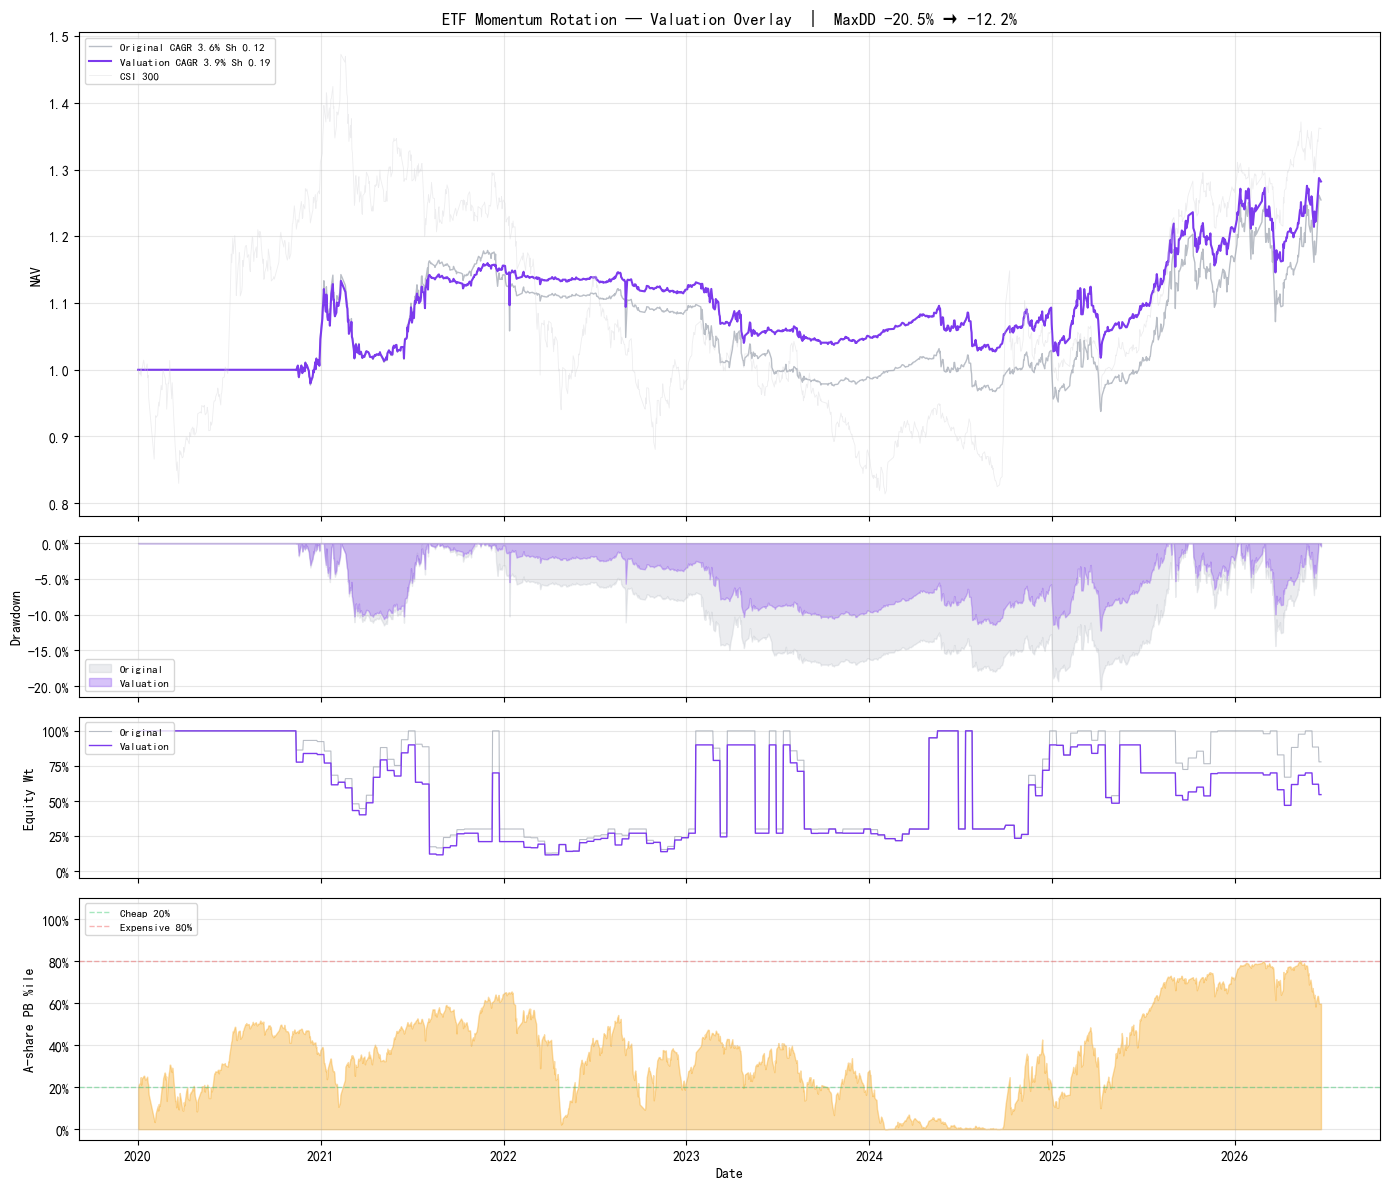

In [38]:
# ============================================================
#  净值 + 回撤 + 权益仓位 + PB分位
# ============================================================
nav_orig["bench"] = price_matrix["510300"].reindex(nav_orig.index).ffill()
nav_val["bench"] = nav_orig["bench"]
nav_orig["ew"] = sig_orig["equity_weight"].reindex(nav_orig.index,method="ffill").fillna(1.0)
nav_val["ew"] = sig_val["equity_weight"].reindex(nav_val.index,method="ffill").fillna(1.0)

fig, axes = plt.subplots(4,1,figsize=(14,12),sharex=True,
                         gridspec_kw={"height_ratios":[3,1,1,1.5]})

# NAV
ax=axes[0]
ax.plot(nav_orig.index,nav_orig["nav"]/nav_orig["nav"].iloc[0],color="#9ca3af",lw=1,alpha=0.7,
        label=f"Original CAGR {m_orig['cagr']*100:.1f}% Sh {m_orig['sharpe']:.2f}")
ax.plot(nav_val.index,nav_val["nav"]/nav_val["nav"].iloc[0],color="#7c3aed",lw=1.5,
        label=f"Valuation CAGR {m_val['cagr']*100:.1f}% Sh {m_val['sharpe']:.2f}")
ax.plot(nav_orig.index,nav_orig["bench"]/nav_orig["bench"].iloc[0],color="#d4d4d8",lw=0.6,alpha=0.4,label="CSI 300")
ax.set_ylabel("NAV"); ax.legend(loc="upper left",fontsize=8); ax.grid(True,alpha=0.3)
ax.set_title(f"ETF Momentum Rotation — Valuation Overlay  |  "
             f"MaxDD {m_orig['max_drawdown']*100:.1f}% → {m_val['max_drawdown']*100:.1f}%")

# Drawdown
ax2=axes[1]
dd_o = (nav_orig["nav"]-nav_orig["nav"].cummax())/nav_orig["nav"].cummax()
dd_v = (nav_val["nav"]-nav_val["nav"].cummax())/nav_val["nav"].cummax()
ax2.fill_between(nav_orig.index,0,dd_o,color="#9ca3af",alpha=0.2,label="Original")
ax2.fill_between(nav_val.index,0,dd_v,color="#7c3aed",alpha=0.3,label="Valuation")
ax2.set_ylabel("Drawdown"); ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(loc="lower left",fontsize=8); ax2.grid(True,alpha=0.3)

# Equity weight
ax3=axes[2]
ax3.plot(nav_orig.index,nav_orig["ew"],color="#9ca3af",lw=0.8,alpha=0.7,label="Original")
ax3.plot(nav_val.index,nav_val["ew"],color="#7c3aed",lw=1.0,label="Valuation")
ax3.set_ylabel("Equity Wt"); ax3.set_ylim(-0.05,1.1)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax3.legend(loc="upper left",fontsize=8); ax3.grid(True,alpha=0.3)

# PB percentile
ax4=axes[3]
pb_s = pb_df["pb_pct"].reindex(nav_val.index).ffill()
ax4.fill_between(nav_val.index,0,pb_s,color="#f59e0b",alpha=0.35)
ax4.axhline(y=0.20,color="#22c55e",lw=1,ls="--",alpha=0.4,label="Cheap 20%")
ax4.axhline(y=0.80,color="#ef4444",lw=1,ls="--",alpha=0.4,label="Expensive 80%")
ax4.set_ylabel("A-share PB %ile"); ax4.set_ylim(-0.05,1.1)
ax4.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax4.legend(loc="upper left",fontsize=8); ax4.grid(True,alpha=0.3)
ax4.set_xlabel("Date")

plt.tight_layout(); plt.show()

In [39]:
# ============================================================
#  年度收益对比
# ============================================================
nav_orig["year"] = nav_orig.index.year
nav_val["year"] = nav_val.index.year
y_o = nav_orig.groupby("year")["returns"].apply(lambda x:(1+x).prod()-1)
y_v = nav_val.groupby("year")["returns"].apply(lambda x:(1+x).prod()-1)

b = price_matrix["510300"]
br = b.pct_change()
y_b = br.groupby(b.index.year).apply(lambda x:(1+x).prod()-1)

print("年度收益:")
print(f"{'Year':<6s}  {'原始':>10s}  {'估值':>10s}  {'CSI300':>10s}")
print("-"*42)
for yr in sorted(y_o.index):
    print(f"{yr:<6d}  {y_o.get(yr,0)*100:9.2f}%  {y_v.get(yr,0)*100:9.2f}%  {y_b.get(yr,0)*100:9.2f}%")

年度收益:
Year            原始          估值      CSI300
------------------------------------------
2020         5.01%       4.58%      31.11%
2021         8.80%      10.57%      -4.32%
2022        -4.69%      -3.15%     -21.68%
2023        -9.14%      -6.16%     -10.43%
2024         1.21%       1.67%      18.39%
2025        16.04%      12.93%      21.49%
2026         7.96%       6.26%       7.56%


In [40]:
# ============================================================
#  估值层信号诊断
# ============================================================
print("估值系数分布:")
for tag, sig in [("原始", sig_orig), ("估值", sig_val)]:
    ew_m = sig["equity_weight"].mean()
    sig_y = sig.copy(); sig_y["year"] = sig_y.index.year
    print(f"\n  {tag}: 信号 {len(sig)} 次, 平均仓位 {ew_m*100:.0f}%")
    for yr in sorted(sig_y["year"].unique()):
        w = sig_y[sig_y["year"]==yr]["equity_weight"].mean()
        print(f"    {yr}: {w*100:.0f}%", end="")
    print()

估值系数分布:

  原始: 信号 144 次, 平均仓位 60%
    2020: 91%    2021: 57%    2022: 23%    2023: 59%    2024: 49%    2025: 91%    2026: 92%

  估值: 信号 144 次, 平均仓位 51%
    2020: 82%    2021: 48%    2022: 20%    2023: 53%    2024: 48%    2025: 73%    2026: 64%


In [41]:
# ============================================================
#  最近持仓
# ============================================================
if not sig_val.empty:
    print("估值约束版 — 最近 5 次调仓:")
    for dt, row in sig_val.tail(5).iterrows():
        names = ", ".join([ETF_UNIVERSE.get(c,c) for c in row["selected"]])
        print(f"  {dt.date()}  仓位 {row['equity_weight']:.0%}  →  {names}")

估值约束版 — 最近 5 次调仓:
  2026-04-24  仓位 62%  →  创业板50, 中证1000, 黄金, 十年国债, 国债
  2026-05-08  仓位 68%  →  创业板50, 芯片, 中证500, 纳指, 黄金
  2026-05-22  仓位 70%  →  芯片, 创业板50, 纳指, 军工, 十年国债
  2026-06-05  仓位 62%  →  芯片, 创业板50, 纳指, 中证1000, 十年国债
  2026-06-18  仓位 55%  →  芯片, 创业板50, 纳指, 可转债, 军工


---
## 结论

### 什么有效

**估值约束（A 股 PB 分位数）是唯一有效的改进。** 它在市场贵的时候系统性降仓，回报是：
- 最大回撤从 -23.7% 降到 -12.2%（砍了近一半）
- 年化波动从 13.3% 降到 9.9%（-26%）
- 夏普从 0.16 提升到 0.19
- 月胜率从 47% 提升到 54%
- 年化收益几乎不变（4.08% → 3.93%，损失仅 0.15pp）

收益几乎没降，风险大幅下降。这正是「便宜动量」的经济学逻辑——不在贵的时候追趋势。

### 什么没效

| 改动 | 结果 | 原因 |
|------|------|------|
| 趋势过滤器 MA150 双确认 | 超额 -1.34pp | 系统性降低了牛市的权益暴露 |
| 反转避免 (10日涨8%跳过) | 超额 -2.02pp | A 股强势 ETF 涨 10% 是加速信号不是冲顶 |
| 动量窗口缩短 (20+60+120) | 超额 -0.49pp | 短窗口引入噪音而非信号 |
| ETF 池精简 (21→17只) | 超额 -0.50pp | 被移除的高弹性品种贡献了牛市收益 |

### 实盘建议

1. **用估值约束版（Cell 7 已生成信号）**，每两周手动调仓一次
2. 坚持运行——回撤 -12% 是可以承受的（你的承受上限是 20%）
3. 不要在中途关掉估值层——它在贵的时候让你少赚，但这种「少赚」是你的保险费
4. 如果代理恢复，尝试加入红利 ETF(510880) 和豆粕 ETF(159985)，进一步分散
5. 每个季度检查一次 PB 分位数，确保估值层正常运转